# **PPAR-Gamma Pocket Selection Visualizer**

**Notebook 01: 3D Visualization of Protein Structures and Extracted Binding Pockets**

**Features:**
1. Comparison of full protein vs extracted pocket
2. Residue-level feature inspection

----
- **Author:** Aaryesh Deshpande
- **Date:** October 26, 2025

## Setup and Imports

In [184]:
import sys
from pathlib import Path
import pickle
import numpy as np
import pandas as pd
import nglview as nv
import MDAnalysis as mda
from IPython.display import display
import warnings

# Add src to path for imports
project_root = Path.cwd().parent
sys.path.insert(0, str(project_root / "src"))

from pprag.dataio.schema import AA_ORDER    # noqa
from pprag.dataio import schema     # noqa

sys.modules['schema'] = schema
warnings.filterwarnings('ignore')

# Paths to data
pockets_csv = project_root / "Data" / "meta" / "pockets.csv"
pockets_output_dir = project_root / "Output" / "pockets"

if not pockets_csv.exists():
    print(f"Warning: {pockets_csv} not found")
else:
    print(f"Found pockets CSV: {pockets_csv}")

if not pockets_output_dir.exists():
    print(f"Warning: {pockets_output_dir} not found")
else:
    pocket_files = list(pockets_output_dir.glob("*.pkl"))
    print(f"Found {len(pocket_files)} pocket files in {pockets_output_dir}")

Found pockets CSV: /mnt/f/Coursework/MSBINF/CSE8803-MLG/Project/mlg-project-repo-t6/Data/meta/pockets.csv
Found 160 pocket files in /mnt/f/Coursework/MSBINF/CSE8803-MLG/Project/mlg-project-repo-t6/Output/pockets


## **Load Available Pockets**

List all available protein-pocket pairs:

In [185]:
# Load pockets catalog
if pockets_csv.exists():
    pockets_df = pd.read_csv(pockets_csv)
    print(f"\nAvailable protein structures: {len(pockets_df)}")
    print("\nSample entries:")
    display(pockets_df.head(10))

    # Count by state
    state_counts = pockets_df['state'].value_counts()
    print("\nDistribution by state:")
    for state, count in state_counts.items():
        print(f"   {state}: {count}")
else:
    print("No pockets CSV found. Please check your data directory.")
    pockets_df = None


Available protein structures: 160

Sample entries:


,target_id,pdb_path,ligand_path,state
0,1FM6,/mnt/f/Coursework/MSBINF/CSE8803-MLG/Project/m...,/mnt/f/Coursework/MSBINF/CSE8803-MLG/Project/m...,agonist
1,1FM9,/mnt/f/Coursework/MSBINF/CSE8803-MLG/Project/m...,/mnt/f/Coursework/MSBINF/CSE8803-MLG/Project/m...,agonist
2,1I7I,/mnt/f/Coursework/MSBINF/CSE8803-MLG/Project/m...,/mnt/f/Coursework/MSBINF/CSE8803-MLG/Project/m...,agonist
3,1K74,/mnt/f/Coursework/MSBINF/CSE8803-MLG/Project/m...,/mnt/f/Coursework/MSBINF/CSE8803-MLG/Project/m...,agonist
4,1KNU,/mnt/f/Coursework/MSBINF/CSE8803-MLG/Project/m...,/mnt/f/Coursework/MSBINF/CSE8803-MLG/Project/m...,agonist
5,1NYX,/mnt/f/Coursework/MSBINF/CSE8803-MLG/Project/m...,/mnt/f/Coursework/MSBINF/CSE8803-MLG/Project/m...,agonist
6,1RDT,/mnt/f/Coursework/MSBINF/CSE8803-MLG/Project/m...,/mnt/f/Coursework/MSBINF/CSE8803-MLG/Project/m...,agonist
7,1WM0,/mnt/f/Coursework/MSBINF/CSE8803-MLG/Project/m...,/mnt/f/Coursework/MSBINF/CSE8803-MLG/Project/m...,agonist
8,1ZEO,/mnt/f/Coursework/MSBINF/CSE8803-MLG/Project/m...,/mnt/f/Coursework/MSBINF/CSE8803-MLG/Project/m...,agonist
9,1ZGY,/mnt/f/Coursework/MSBINF/CSE8803-MLG/Project/m...,/mnt/f/Coursework/MSBINF/CSE8803-MLG/Project/m...,agonist



Distribution by state:
   agonist: 80
   antagonist: 80


## **Select Protein Structure to Visualize**

Choose a structure by index or target_id:

In [186]:
# SELECT STRUCTURE HERE
# Option 1: By index
selected_idx = 0

# Option 2: By target_id (uncomment and modify)
# selected_target_id = "1FM6"
# selected_state = "agonist"
# selected_idx = pockets_df[
#     (pockets_df['target_id'] == selected_target_id) &
#     (pockets_df['state'] == selected_state)
# ].index[0]

In [187]:
if pockets_df is not None and selected_idx < len(pockets_df):
    selected = pockets_df.iloc[selected_idx]

    print("\nSELECTED STRUCTURE:")
    print(f"- Target ID: {selected['target_id']}")
    print(f"- State: {selected['state']}")
    print(f"- Protein MOL2: {selected['pdb_path']}")
    if pd.notna(selected['ligand_path']):
        print(f"- Ligand MOL2: {selected['ligand_path']}")
    else:
        print("Ligand: No co-complexed ligand")

    # Check if files exist
    protein_path = project_root / selected['pdb_path']
    if not protein_path.exists():
        print(f"Warning: Protein file not found at {protein_path}")
    else:
        print("Protein file found")

    if pd.notna(selected['ligand_path']):
        ligand_path = project_root / selected['ligand_path']
        if not ligand_path.exists():
            print(f"Warning: Ligand file not found at {ligand_path}")
        else:
            print("Ligand file found")

    # Load corresponding PocketSelect object
    pocket_pkl_name = f"{selected['target_id']}__{selected['state']}.pkl"
    pocket_pkl_path = pockets_output_dir / pocket_pkl_name

    if pocket_pkl_path.exists():
        with open(pocket_pkl_path, 'rb') as f:
            pocket_select = pickle.load(f)
        print(f"Loaded PocketSelect: {len(pocket_select.residues)} residues")
    else:
        print(f"Warning: PocketSelect file not found at {pocket_pkl_path}")
        pocket_select = None
else:
    print("Invalid selection or no data available")
    selected = None
    pocket_select = None


SELECTED STRUCTURE:
- Target ID: 1FM6
- State: agonist
- Protein MOL2: /mnt/f/Coursework/MSBINF/CSE8803-MLG/Project/mlg-project-repo-t6/Data/PPAR_gamma/PPAR_gamma_agonist/targets/1FM6/1FM6_prot.mol2
- Ligand MOL2: /mnt/f/Coursework/MSBINF/CSE8803-MLG/Project/mlg-project-repo-t6/Data/PPAR_gamma/PPAR_gamma_agonist/targets/1FM6/1FM6_ligand_prot.mol2
Protein file found
Ligand file found
Loaded PocketSelect: 38 residues


## **Visualize Full Protein Structure**

Interactive 3D view of the complete protein:

- Secondary structure cartoon representation
- Optional surface representation
- Co-crystallized ligand

In [188]:
if selected is not None:
    protein_path = project_root / selected['pdb_path']

    if protein_path.exists():
        u_full = mda.Universe(str(protein_path))
        protein_atoms = u_full.select_atoms("protein")

        print("\nProtein Statistics:")
        print(f"- Total atoms: {u_full.atoms.n_atoms}")
        print(f"- Protein atoms: {protein_atoms.n_atoms}")
        print(f"- Residues: {protein_atoms.n_residues}")

        view_full = nv.show_mdanalysis(protein_atoms)

        view_full.clear_representations()

        # Secondary structure cartoon
        view_full.add_cartoon(selection="protein", color="sstruc", opacity=0.7)

        # Add surface representation - uncomment for surface view
        # view_full.add_surface(selection="protein", color="lightblue", opacity=0.3)

        # Add ligand
        if pd.notna(selected['ligand_path']):
            ligand_path = project_root / selected['ligand_path']
            if ligand_path.exists():
                u_lig = mda.Universe(str(ligand_path))
                lig_atoms = u_lig.select_atoms("not protein")
                if lig_atoms.n_atoms == 0:
                    lig_atoms = u_lig.atoms

                print(f"- Ligand atoms: {lig_atoms.n_atoms}")

                # Add ligand to view - combine universes
                view_full.add_component(nv.MDAnalysisTrajectory(lig_atoms))

        view_full.center()

        print(f"\nFull Protein Structure: {selected['target_id']} ({selected['state']})")
        display(view_full)
    else:
        print("Cannot visualize: protein file not found")
else:
    print("No structure selected")


Protein Statistics:
- Total atoms: 4709
- Protein atoms: 4709
- Residues: 288
- Ligand atoms: 43

Full Protein Structure: 1FM6 (agonist)


NGLWidget()

## **Visualize Extracted Pocket**

Show only the residues selected for the binding pocket:

Our pocket selection criteria was based on flex-distance from the ligand (10 Angstrom cutoff).


In [189]:
if selected is not None and pocket_select is not None:
    protein_path = project_root / selected['pdb_path']

    if protein_path.exists():
        u_pocket = mda.Universe(str(protein_path))

        # Select only pocket residues
        resid_list = " or ".join([f"resid {r}" for r in pocket_select.residues])
        pocket_atoms = u_pocket.select_atoms(f"protein and ({resid_list})")

        print("\nPocket Statistics:")
        print(f"- Selected residues: {len(pocket_select.residues)}")
        print(f"- Pocket atoms: {pocket_atoms.n_atoms}")

        # Get pocket center - average CA positions
        ca_positions = np.array([feat.ca_xyz for feat in pocket_select.feats])
        pocket_center = ca_positions.mean(axis=0)
        print(f"- Pocket center: ({pocket_center[0]:.2f}, {pocket_center[1]:.2f}, {pocket_center[2]:.2f})")

        view_pocket = nv.show_mdanalysis(pocket_atoms)
        view_pocket.clear_representations()

        view_pocket.add_cartoon(selection="protein", color="residueindex", opacity=0.65)
        view_pocket.add_hyperball(selection="protein", color="residueindex", opacity=0.15)

        if pd.notna(selected['ligand_path']):
            ligand_path = project_root / selected['ligand_path']
            if ligand_path.exists():
                u_lig = mda.Universe(str(ligand_path))
                lig_atoms = u_lig.select_atoms("not protein")
                if lig_atoms.n_atoms == 0:
                    lig_atoms = u_lig.atoms

                view_pocket.add_component(nv.MDAnalysisTrajectory(lig_atoms))
                view_pocket.add_representation(
                    "label",
                    selection="not protein",
                    component=1,
                    labelType="resname",
                    showBackground=True,
                    color="black",
                    xOffset=0.5,
                    labelSize=3.0,
                    zOffset=5
                )

        view_pocket.center(component=1)

        print(f"\nBinding Pocket: {selected['target_id']} ({selected['state']})")
        display(view_pocket)
    else:
        print("Cannot visualize: protein file not found")
else:
    print("No pocket data available")



Pocket Statistics:
- Selected residues: 38
- Pocket atoms: 666
- Pocket center: (16.17, -20.10, 11.10)

Binding Pocket: 1FM6 (agonist)


NGLWidget()

## **Superimposing the pocket onto the full protein structure**

In [190]:
if selected is not None and pocket_select is not None:
    protein_path = project_root / selected['pdb_path']

    if protein_path.exists():
        u_full = mda.Universe(str(protein_path))
        protein_full = u_full.select_atoms("protein")

        resid_list = " or ".join([f"resid {r}" for r in pocket_select.residues])
        pocket_atoms = u_full.select_atoms(f"protein and ({resid_list})")

        # Full protein view
        view1 = nv.show_mdanalysis(protein_full)
        view1.clear_representations()
        view1.add_cartoon(selection="protein", color="lightgreen", opacity=0.5)

        # Highlight pocket residues on full protein (NGLView expects 'resi 12 34 56')
        pocket_resi_str = "resi " + " ".join(str(r) for r in pocket_select.residues)
        view1.add_ball_and_stick(selection=pocket_resi_str, color="red", opacity=0.5)
        view1.add_surface(selection=pocket_resi_str, color="pink", opacity=0.2)

        # Add ligand to both views if present
        if pd.notna(selected['ligand_path']):
            ligand_path = project_root / selected['ligand_path']
            if ligand_path.exists():
                u_lig = mda.Universe(str(ligand_path))
                lig_atoms = u_lig.select_atoms("not protein")
                if lig_atoms.n_atoms == 0:
                    lig_atoms = u_lig.atoms

                view1.add_component(nv.MDAnalysisTrajectory(lig_atoms))
                view1.add_ball_and_stick(selection="not protein", color="green")

        view1.center()

        print(f"\nSuperimposed extracted pocket onto {selected['target_id']} ({selected['state']})")
        display(view1)

    else:
        print("Cannot visualize: protein file not found")
else:
    print("No data available for comparison")


Superimposed extracted pocket onto 1FM6 (agonist)


NGLWidget()

## **Pocket Residue Features**

In [191]:
if pocket_select is not None:
    residue_data = []

    for feat in pocket_select.feats:
        aa_letter = AA_ORDER[feat.aa_idx] if feat.aa_idx < len(AA_ORDER) else 'X'

        residue_data.append({
            'Residue_ID': feat.resid,
            'AA': aa_letter,
            'SASA': f"{feat.sasa:.1f}",
            'Hydropathy': f"{feat.hydropathy:.2f}",
            'Charge': feat.charge_class,
            'HBD': feat.hbd,
            'HBA': feat.hba,
            'CA_x': f"{feat.ca_xyz[0]:.2f}",
            'CA_y': f"{feat.ca_xyz[1]:.2f}",
            'CA_z': f"{feat.ca_xyz[2]:.2f}",
        })

    residue_df = pd.DataFrame(residue_data)

    print(f"\nPocket Residue Features: {selected['target_id']} ({selected['state']})")
    print(f"\nTotal residues in pocket: {len(residue_df)}")

    # Summary statistics
    print("\nFeature Summary:")
    print(f"- SASA range: {residue_df['SASA'].astype(float).min():.1f} - {residue_df['SASA'].astype(float).max():.1f} Ų")
    print(f"- Hydropathy range: {residue_df['Hydropathy'].astype(float).min():.2f} - {residue_df['Hydropathy'].astype(float).max():.2f}")
    print(f"- Charge distribution: {residue_df['Charge'].value_counts().to_dict()}")
    print(f"- Total HBD: {residue_df['HBD'].sum()}")
    print(f"- Total HBA: {residue_df['HBA'].sum()}")

    print("\nFull Residue Table:")
    display(residue_df)
else:
    print("No pocket data available")


Pocket Residue Features: 1FM6 (agonist)

Total residues in pocket: 38

Feature Summary:
- SASA range: 200.0 - 200.0 Ų
- Hydropathy range: -2.49 - 3.07
- Charge distribution: {0: 34, 1: 3, -1: 1}
- Total HBD: 16
- Total HBA: 14

Full Residue Table:


,Residue_ID,AA,SASA,Hydropathy,Charge,HBD,HBA,CA_x,CA_y,CA_z
0,65,L,200.0,1.94,0,0,0,23.50,-30.82,15.59
1,73,A,200.0,0.53,0,0,0,12.22,-23.14,21.39
2,74,I,200.0,2.40,0,0,0,16.01,-23.57,21.53
3,75,R,200.0,-2.49,1,3,0,16.11,-26.56,19.16
4,76,I,200.0,2.40,0,0,0,14.32,-24.55,16.46
5,77,F,200.0,3.07,0,0,0,16.54,-21.51,17.10
6,78,Q,200.0,-1.87,0,1,1,19.64,-23.68,16.73
7,79,G,200.0,0.03,0,0,0,18.12,-25.18,13.59
8,80,C,200.0,1.60,0,1,1,17.74,-21.79,11.92
9,81,Q,200.0,-1.87,0,1,1,21.33,-21.07,12.86


## **Feature Distribution Analysis**

Visualize the distribution of molecular features across pocket residues

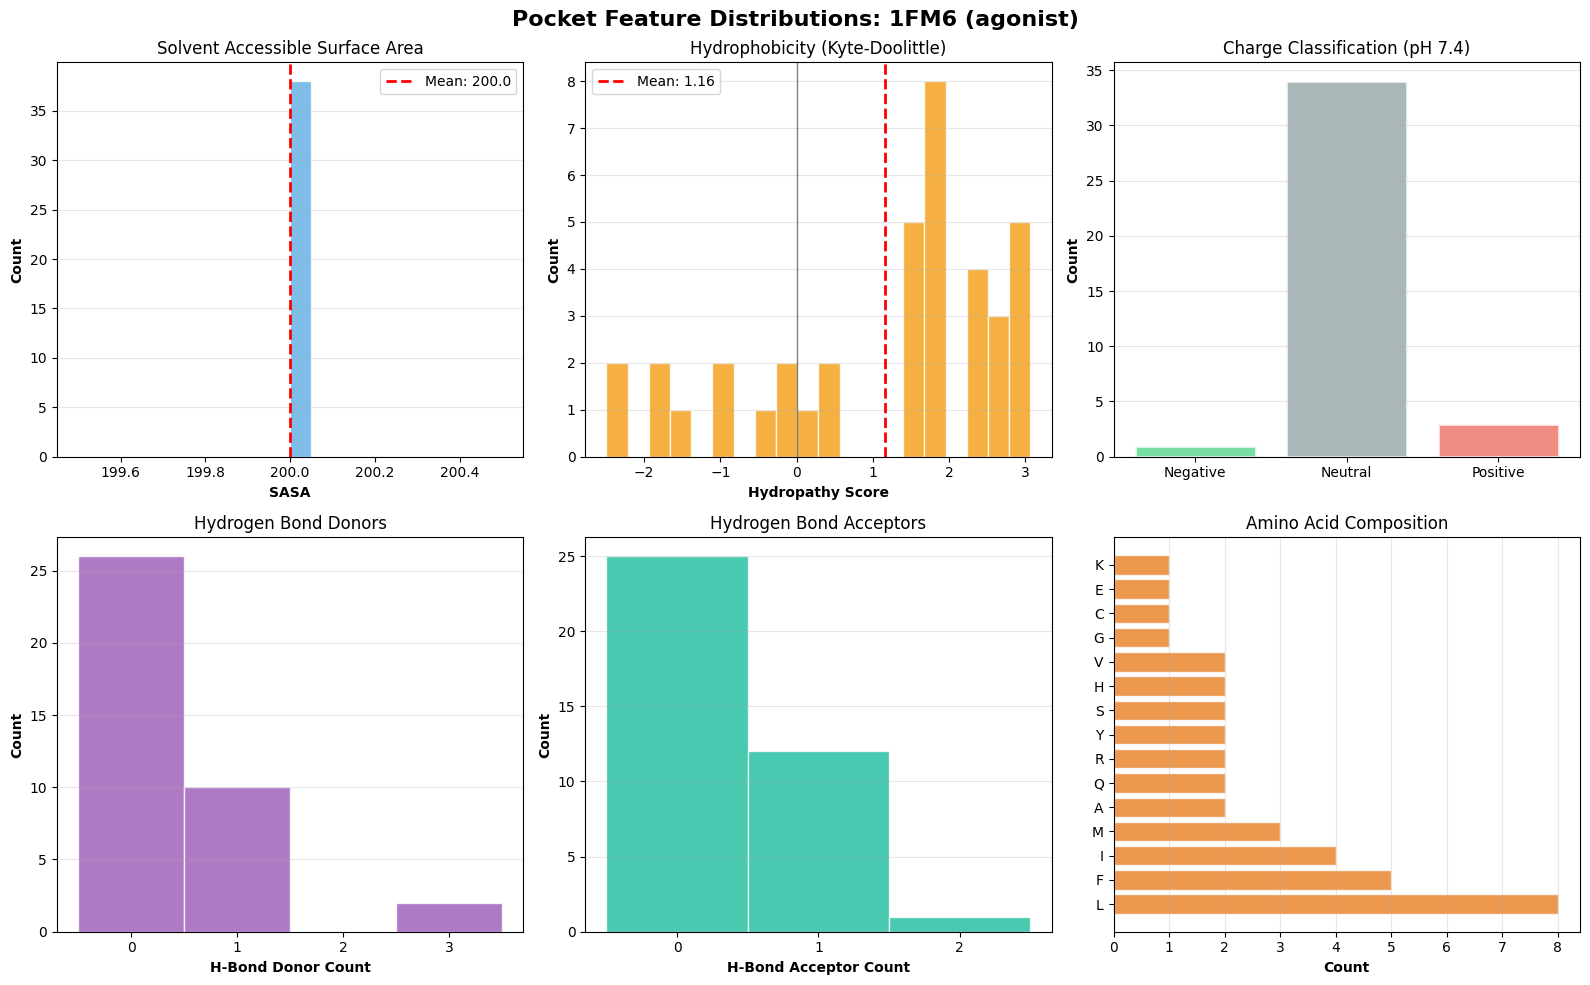

In [192]:
if pocket_select is not None:
    import matplotlib.pyplot as plt

    sasa_values = [feat.sasa for feat in pocket_select.feats]
    hydropathy_values = [feat.hydropathy for feat in pocket_select.feats]
    charge_values = [feat.charge_class for feat in pocket_select.feats]
    hbd_values = [feat.hbd for feat in pocket_select.feats]
    hba_values = [feat.hba for feat in pocket_select.feats]

    fig, axes = plt.subplots(2, 3, figsize=(16, 10))
    fig.suptitle(f'Pocket Feature Distributions: {selected["target_id"]} ({selected["state"]})',
                fontsize=16, fontweight='bold')

    # SASA
    axes[0, 0].hist(sasa_values, bins=20, color='#5DADE2', edgecolor='white', alpha=0.8)
    axes[0, 0].set_xlabel('SASA', fontweight='bold')
    axes[0, 0].set_ylabel('Count', fontweight='bold')
    axes[0, 0].set_title('Solvent Accessible Surface Area')
    axes[0, 0].axvline(np.mean(sasa_values), color='red', linestyle='--', linewidth=2,
                      label=f'Mean: {np.mean(sasa_values):.1f}')
    axes[0, 0].legend()
    axes[0, 0].grid(axis='y', alpha=0.3)

    # Hydropathy distribution
    axes[0, 1].hist(hydropathy_values, bins=20, color='#F39C12', edgecolor='white', alpha=0.8)
    axes[0, 1].set_xlabel('Hydropathy Score', fontweight='bold')
    axes[0, 1].set_ylabel('Count', fontweight='bold')
    axes[0, 1].set_title('Hydrophobicity (Kyte-Doolittle)')
    axes[0, 1].axvline(0, color='black', linestyle='-', linewidth=1, alpha=0.5)
    axes[0, 1].axvline(np.mean(hydropathy_values), color='red', linestyle='--', linewidth=2,
                      label=f'Mean: {np.mean(hydropathy_values):.2f}')
    axes[0, 1].legend()
    axes[0, 1].grid(axis='y', alpha=0.3)

    # Charge distribution
    charge_counts = pd.Series(charge_values).value_counts().sort_index()
    charge_labels = {-1: 'Negative', 0: 'Neutral', 1: 'Positive'}
    colors_charge = {-1: '#58D68D', 0: '#95A5A6', 1: '#EC7063'}

    axes[0, 2].bar([charge_labels[c] for c in charge_counts.index],
                  charge_counts.values,
                  color=[colors_charge[c] for c in charge_counts.index],
                  edgecolor='white', alpha=0.8, linewidth=2)
    axes[0, 2].set_ylabel('Count', fontweight='bold')
    axes[0, 2].set_title('Charge Classification (pH 7.4)')
    axes[0, 2].grid(axis='y', alpha=0.3)

    # HBD distribution
    axes[1, 0].hist(hbd_values, bins=range(max(hbd_values)+2), color='#9B59B6',
                   edgecolor='white', alpha=0.8, align='left')
    axes[1, 0].set_xlabel('H-Bond Donor Count', fontweight='bold')
    axes[1, 0].set_ylabel('Count', fontweight='bold')
    axes[1, 0].set_title('Hydrogen Bond Donors')
    axes[1, 0].set_xticks(range(max(hbd_values)+1))
    axes[1, 0].grid(axis='y', alpha=0.3)

    # HBA distribution
    axes[1, 1].hist(hba_values, bins=range(max(hba_values)+2), color='#1ABC9C',
                   edgecolor='white', alpha=0.8, align='left')
    axes[1, 1].set_xlabel('H-Bond Acceptor Count', fontweight='bold')
    axes[1, 1].set_ylabel('Count', fontweight='bold')
    axes[1, 1].set_title('Hydrogen Bond Acceptors')
    axes[1, 1].set_xticks(range(max(hba_values)+1))
    axes[1, 1].grid(axis='y', alpha=0.3)

    # Amino acid composition
    aa_counts = pd.Series([AA_ORDER[feat.aa_idx] for feat in pocket_select.feats]).value_counts()
    axes[1, 2].barh(range(len(aa_counts)), aa_counts.values, color='#E67E22',
                   edgecolor='white', alpha=0.8)
    axes[1, 2].set_yticks(range(len(aa_counts)))
    axes[1, 2].set_yticklabels(aa_counts.index)
    axes[1, 2].set_xlabel('Count', fontweight='bold')
    axes[1, 2].set_title('Amino Acid Composition')
    axes[1, 2].grid(axis='x', alpha=0.3)

    plt.tight_layout()
    plt.show()
else:
    print("No pocket data available")

---